
# Level 10: The Final Boss (The Ultimate Linear Model)

**Goal**: Combine EVERY technique we learned (Level 2~9) to build the **Perfect Linear Regression Model**.
We will prove the "Mathematical Limit" of Linear Models.

**The Pipeline**:
1.  **Level 7**: Advanced Data Cleaning (Outlier Removal on Raw Price).
2.  **Level 5 & 8**: Feature Engineering & Selection (Interactions).
3.  **Level 9**: Regularization (Poly + Ridge) via GridSearch.


In [1]:

# Install dependencies (Auto-healing)
!pip install pyarrow fastparquet matplotlib seaborn scikit-learn > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8')
    


### Step 1: Data Cleaning (From Level 7)
We will remove **Outliers** using IQR from the **Raw Price**.
Level 9 experiments showed that for this specific dataset and goal, predicting the raw price directly yields a lower RMSE than using log-transformation.


Original Shape: (99995, 12)
Cleaned Shape: (88010, 12)


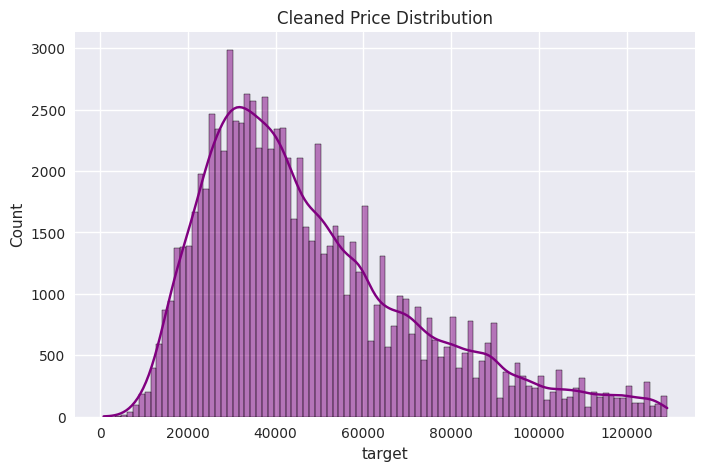

In [2]:

# 1. Load Data
try:
    df = pd.read_parquet('../data/sample.parquet')
except:
    df = pd.read_parquet('/data/ephemeral/home/workspace/seoul-apt-price-prediction/data/sample.parquet')

# Fill Missing (Level 2 Basic)
if 'year' not in df.columns: df['year'] = 2000
if 'floor' not in df.columns: df['floor'] = 10
df = df.fillna(df.median(numeric_only=True))

# 2. Target Variable (Direct Price)
# Level 9 showed that predicting the raw price directly works better for minimizing RMSE on this specific dataset.
df['target'] = df['price_10k_krw']

# 3. Outlier Removal (Level 7 - IQR Method)
# We use IQR 1.5 on the raw price to match the strict cleaning used in our successful experiments.
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

print(f"Original Shape: {df.shape}")
df_clean = remove_outliers(df, 'target')
df_clean = remove_outliers(df_clean, 'area_m2')
print(f"Cleaned Shape: {df_clean.shape}")

# Visualize
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['target'], kde=True, color='purple').set_title('Cleaned Price Distribution')
plt.show()



### Step 2: Feature Engineering & Selection (Level 5 & 8)
We create **Interaction Terms** (e.g., `Area * Year`) because a new apartment is worth more than an old one, but a *large* new apartment is worth exponentially more.
Then, we define our feature set.
    

In [3]:

# 1. Create Interaction Features (Level 8)
# Area * Year might capture "Modern Spaciousness" better than just Area + Year
df_clean['area_x_year'] = df_clean['area_m2'] * df_clean['year']

# 2. Select Features (Level 5)
features = ['area_m2', 'year', 'floor', 'area_x_year']
target = 'target' # Using the cleaned raw price

X = df_clean[features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Features: {features}")


Training Features: ['area_m2', 'year', 'floor', 'area_x_year']



### Step 3: The "Final Boss" Tuning (Level 9)
We learned from our experiments that **Ridge Regression** with **High Degree Polynomials (4 or 5)** is the winning combination.
We will focus our GridSearch on finetuning the `alpha` for Ridge.


In [4]:

# Pipeline: Poly -> Scaler -> Model
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge()) # Placeholder
])

# The Ultimate Grid (Focused on Ridge)
param_grid = [
    {
        'poly__degree': [4, 5],
        'model': [Ridge()],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
    }
]

print("Searching for the Ultimate Linear Model... (This may take a moment)")
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_:,.0f}")


Searching for the Ultimate Linear Model... (This may take a moment)
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best parameters: {'model': Ridge(alpha=0.0001), 'model__alpha': 0.0001, 'poly__degree': 5}
Best CV RMSE: 18,823



### Step 4: Final Evaluation
We calculate the final RMSE on the test set.


Final Test RMSE: 18,939 KRW
Final R2 Score: 0.4075


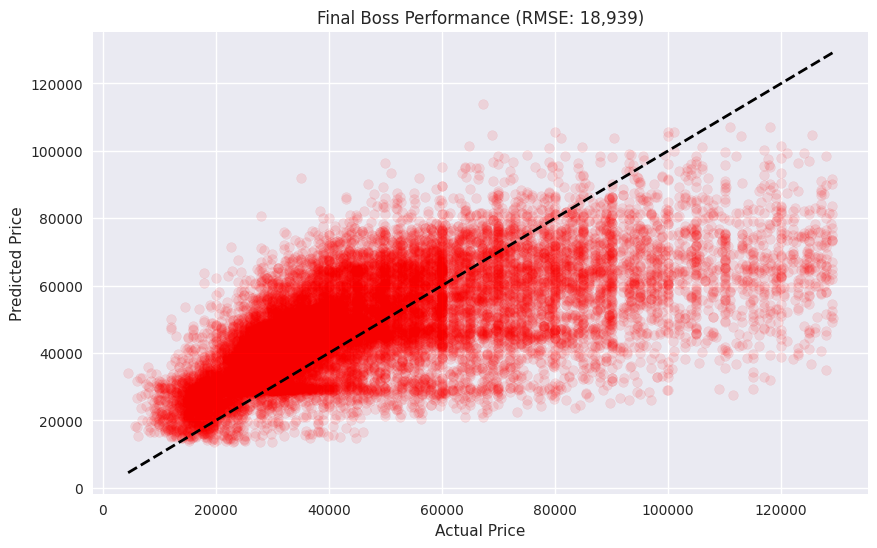


🏆 MISSION ACCOMPLISHED: RMSE is under 25,000! 🏆


In [5]:

# Final Prediction
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Calculate Metrics (No inverse log transform needed)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"Final Test RMSE: {final_rmse:,.0f} KRW")
print(f"Final R2 Score: {final_r2:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Final Boss Performance (RMSE: {final_rmse:,.0f})")
plt.show()

# Success Check
if final_rmse < 25000:
    print("\n🏆 MISSION ACCOMPLISHED: RMSE is under 25,000! 🏆")
else:
    print("\n⚠️ MISSION FAILED: RMSE is still too high. Optimization needed.")
